In [1]:
%pip install tensorflow
%pip install scikit-learn
%pip install Pillow
%pip install tqdm
%pip install nltk
%pip install matplotlib
%pip install numpy
%pip install seaborn

from pathlib import Path
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical, plot_model
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.layers import Input, Dense, LSTM, Embedding, Dropout, add, BatchNormalization
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from PIL import Image
from tqdm import tqdm_notebook
from collections import Counter
from nltk.translate.bleu_score import corpus_bleu
from nltk.translate.meteor_score import meteor_score
from tqdm import tqdm
import os
import re
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import nltk
import tensorflow as tf

# Define the base directory and paths to images and captions
BASE_DIR = Path.cwd()
images = BASE_DIR / "archive" / "Images"
captions = BASE_DIR / "archive" / "captions.txt"

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


...

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


In [2]:
# Function to load captions from the text file
def load_captions(file_path):
    with open(file_path, 'r') as f:
        captions = f.readlines()
        captions = [caption.lower().strip() for caption in captions[1:]]
    return captions

# Function to load image file names from the specified directory
def load_images(image_path):
    return [f for f in os.listdir(image_path) if f.endswith(('.png', '.jpg', '.jpeg'))]

In [3]:
captions = load_captions(captions)
images = load_images(images)
print(captions[:15:3])
print(images[:15])
print("Captions loaded:", len(captions))
print("Images found:", len(images))
print("Sample captions:", captions[:5])
print("Sample images:", images[:5])

['1000268201_693b08cb0e.jpg,a child in a pink dress is climbing up a set of stairs in an entry way .', '1000268201_693b08cb0e.jpg,a little girl climbing the stairs to her playhouse .', '1001773457_577c3a7d70.jpg,a black dog and a tri-colored dog playing with each other on the road .', '1001773457_577c3a7d70.jpg,two dogs on pavement moving toward each other .', '1002674143_1b742ab4b8.jpg,a small girl in the grass plays with fingerpaints in front of a white canvas with a rainbow on it .']
['1000268201_693b08cb0e.jpg', '1001773457_577c3a7d70.jpg', '1002674143_1b742ab4b8.jpg', '1003163366_44323f5815.jpg', '1007129816_e794419615.jpg', '1007320043_627395c3d8.jpg', '1009434119_febe49276a.jpg', '1012212859_01547e3f17.jpg', '1015118661_980735411b.jpg', '1015584366_dfcec3c85a.jpg', '101654506_8eb26cfb60.jpg', '101669240_b2d3e7f17b.jpg', '1016887272_03199f49c4.jpg', '1019077836_6fc9b15408.jpg', '1019604187_d087bf9a5f.jpg']
Captions loaded: 40455
Images found: 8091
Sample captions: ['1000268201_69

In [5]:
# Clean up captions by removing newlines and extra spaces
def clean_captions(captions):
    cleaned_captions = []
    for caption in captions:
        cleaned_caption = caption.split(',')[1]
        cleaned_caption = re.sub(r'[^\w\s]', '', cleaned_caption)
        cleaned_caption = re.sub(r'\d+', '', cleaned_caption)
        cleaned_caption = re.sub(r'\s+', ' ', cleaned_caption).strip()
        cleaned_captions.append(cleaned_caption)
    return cleaned_captions

cleaned_captions = clean_captions(captions)
print(f"Cleaned Captions: {cleaned_captions[:20:2]}")

Cleaned Captions: ['a child in a pink dress is climbing up a set of stairs in an entry way', 'a little girl climbing into a wooden playhouse', 'a little girl in a pink dress going into a wooden cabin', 'a black dog and a tricolored dog playing with each other on the road', 'two dogs of different breeds looking at each other on the road', 'a little girl covered in paint sits in front of a painted rainbow with her hands in a bowl', 'a small girl in the grass plays with fingerpaints in front of a white canvas with a rainbow on it', 'young girl with pigtails painting outside in the grass', 'a man lays on the bench to which a white dog is also tied', 'a shirtless man lies on a park bench with his dog']


In [6]:
def create_caption_ids(captions, cleaned_captions):
    captions_IDS = []
    for i in range(len(cleaned_captions)):
        item = captions[i].split(',')[0]+'\t' + 'start ' + cleaned_captions[i] + ' end\n'
        captions_IDS.append(item)
    return captions_IDS

captions_IDS = create_caption_ids(captions, cleaned_captions)

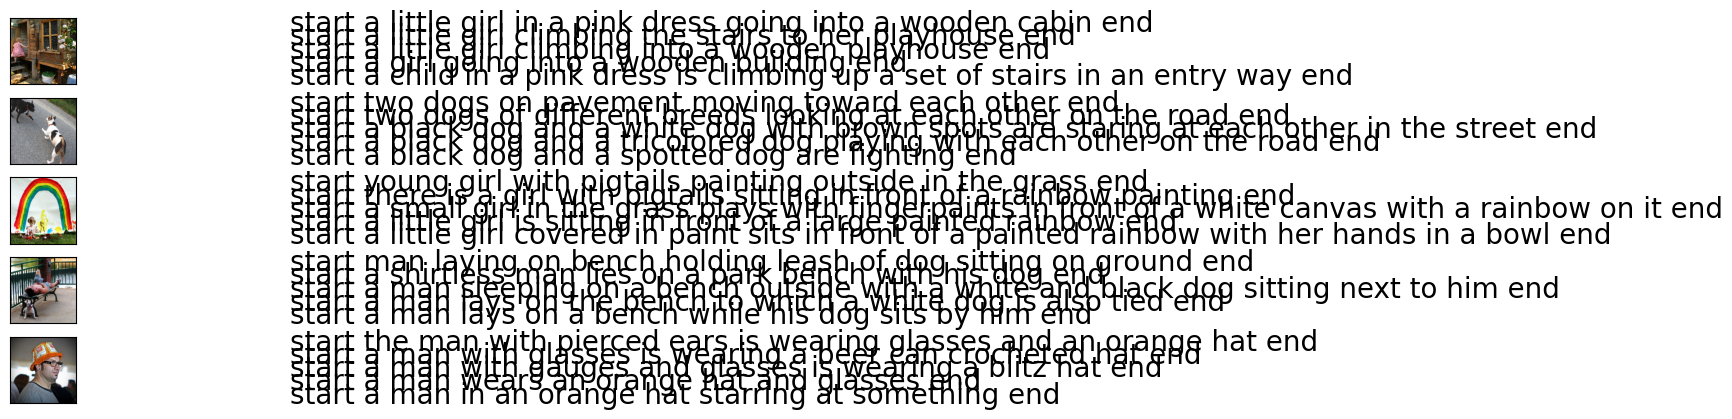

In [7]:
def visualize_captions(captions_IDS, num_samples=5):
    caption_dict = {}
    for caption in captions_IDS:
        image_id, caption_text = caption.split('\t')
        if image_id not in caption_dict:
            caption_dict[image_id] = []
        caption_dict[image_id].append(caption_text.strip())
    else:
        list_captions = [x for x in caption_dict.items()]
    
    count = 1
    fig = plt.figure(figsize=(10, 5))
    for image_id, caption_text in list_captions[:num_samples]:
        captions = caption_dict[image_id]
        image_load = image.load_img(str(BASE_DIR / "archive" / "Images" / image_id), target_size=(224, 224))
        ax = fig.add_subplot(num_samples, 2, count, xticks=[], yticks=[])
        ax.imshow(image_load)
        count += 1

        ax = fig.add_subplot(num_samples, 2 ,count)
        plt.axis("off")
        ax.plot()
        ax.set_xlim(0, 1)
        ax.set_ylim(0, len(captions))
        for i, caption in enumerate(captions):
            ax.text(0, i, caption, fontsize=20)
        count += 1
    plt.show()

# print(f"Caption IDs: {captions_IDS[:20]}")

visualize_captions(captions_IDS, num_samples=5)

In [8]:
all_captions = [caption.split('\t')[1].strip() for caption in captions_IDS]
tokenizer = Tokenizer()
tokenizer.fit_on_texts(all_captions)
vocab_size = len(tokenizer.word_index) + 1
print(f"Vocabulary Size: {vocab_size}")

Vocabulary Size: 8586


In [9]:
def split_dataset(images, captions_IDS):
    train_caption_id, temp_caption_id = train_test_split(images, test_size=0.2, random_state=42)
    val_captions_id, test_captions_id = train_test_split(temp_caption_id, test_size=0.5, random_state=42)
    train_caption, val_caption, test_caption = [], [], []
    for caption in captions_IDS: 
        image_id, _ = caption.split('\t', 1)
        if image_id in train_caption_id:
            train_caption.append(caption)
        elif image_id in val_captions_id:
            val_caption.append(caption)
        elif image_id in test_captions_id:
            test_caption.append(caption)
    return train_caption, val_caption, test_caption, train_caption_id, val_captions_id, test_captions_id

train_captions, val_captions, test_captions, train_caption_id, val_captions_id, test_captions_id = split_dataset(images, captions_IDS)
# print(f"Total captions: {len(images)}")
print(f"Sample training caption: {train_captions[0]}")
print(f"Sample validation caption: {val_captions[0]}")
print(f"Sample test caption: {test_captions[0]}")

Sample training caption: 1000268201_693b08cb0e.jpg	start a child in a pink dress is climbing up a set of stairs in an entry way end

Sample validation caption: 104136873_5b5d41be75.jpg	start people sit on the mountainside and check out the view end

Sample test caption: 1022454428_b6b660a67b.jpg	start a couple and an infant end



In [10]:
# Image feature extraction using a pretrained model (ResNet50)
# include_top=False removes the classifier
# pooling='avg' gives a single 2048-d feature vector for each image
resnet_model = ResNet50(weights='imagenet', include_top=False, pooling='avg')
# Function to extract features for a single image
def extract_image_features(image_path, model):
    img = image.load_img(image_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)
    features = model(img_array, training=False).numpy()  
    return features.flatten()

extract_image_features(str(BASE_DIR / "archive" / "Images" / images[0]), resnet_model)

array([0.0653655 , 0.16782731, 0.3251846 , ..., 0.05111521, 0.3281792 ,
       1.0043341 ], shape=(2048,), dtype=float32)

In [11]:
# Splitting the dataset into training, validation and test sets
# We will use an 80-10-10 split for training, validation and testing respectively
train_image_embeddings, val_image_embeddings, test_image_embeddings = {}, {}, {}
# Function to extract features for the entire dataset
def extract_features_for_dataset(image_path, model, train_captions_id, val_captions_id, test_captions_id, train_image_embeddings, val_image_embeddings, test_image_embeddings):
    pbar = tqdm(total=len(image_path), desc="Extracting image features", ncols =80)
    for image_id in image_path:
        image_embedding = extract_image_features(str(BASE_DIR / "archive" / "Images" / image_id), model)
        if image_id in train_captions_id:
            train_image_embeddings[image_id] = image_embedding.flatten()
        elif image_id in val_captions_id:
            val_image_embeddings[image_id] = image_embedding.flatten()
        elif image_id in test_captions_id:
            test_image_embeddings[image_id] = image_embedding.flatten()
        pbar.update(1)
    pbar.close()
extract_features_for_dataset(images, resnet_model, train_caption_id, val_captions_id, test_captions_id, train_image_embeddings, val_image_embeddings, test_image_embeddings)
print(f"Extracted image features for training set: {len(train_image_embeddings)}")
print(f"Extracted image features for validation set: {len(val_image_embeddings)}")
print(f"Extracted image features for test set: {len(test_image_embeddings)}")

Extracting image features:   0%|              | 17/8091 [00:03<28:12,  4.77it/s]

KeyboardInterrupt: 

In [ ]:
def data_generator(captions, image_embeddings, tokenizer, max_caption_length, batch_size):
    num_samples = len(captions)
    image_ids = list(image_embeddings.keys())
    while True:
        np.random.shuffle(image_ids) # shuffle captions
        for start in range(0, num_samples, batch_size):
            end = min(start + batch_size, num_samples)
            x_images, x_captions, target = [], [], []
            for caption in captions[start:end]:
                image_id, caption_text = caption.split('\t')
                caption_text = caption_text.strip('\n')
                seq = tokenizer.texts_to_sequences([caption_text])[0] # convering the caption text to a sequence of intergs
                for i in range(1, len(seq)):
                    in_seq, out_seq = seq[:i], seq[i] # split the sequence into input and output
                    in_seq = pad_sequences([in_seq], maxlen=max_caption_length)[0] # pad the input sequence to a fixed length
                    out_seq = to_categorical([out_seq], num_classes=vocab_size)[0] # convert the output sequence to one-hot encoding
                    x_images.append(image_embeddings[image_id])
                    x_captions.append(in_seq)
                    target.append(out_seq)
                    yield (np.array(x_images), np.array(x_captions)), np.array(target) # yield the batch of data as a tuple of input and output

max_caption_length = max(len(caption.split()) for caption in cleaned_captions) + 2
cnn_output_dim = resnet_model.output_shape[1] # 2048

batch_size_train = 270
batch_size_val = 150

train_data_generator = data_generator(train_captions, train_image_embeddings, tokenizer, max_caption_length, batch_size_train)
val_data_generator = data_generator(val_captions, val_image_embeddings, tokenizer, max_caption_length, batch_size_val)                

In [ ]:
def build_model(cnn_output_dim, max_caption_length, vocab_size):
    input_image = Input(shape=(cnn_output_dim,) , name='image_input')
    input_caption = Input(shape=(max_caption_length,), name='caption_input')
    fe1 = BatchNormalization()(input_image)
    fe2 = Dense(256, activation='relu')(fe1)
    fe3 = BatchNormalization()(fe2)
    se1 = Embedding(vocab_size, 256, mask_zero=True)(input_caption)
    se2 = LSTM(256)(se1)
    decoder1 = add([fe3, se2])
    decoder2 = Dense(256, activation='relu')(decoder1)
    outputs = Dense(vocab_size, activation='softmax', name='output')(decoder2)
    model = Model(inputs=[input_image, input_caption], outputs=outputs, name='Image_Caption_Generator')
    return model

captain_model = build_model(cnn_output_dim, max_caption_length, vocab_size)
optimzer = Adam(learning_rate=0.001, clipnorm=1.0)
captain_model.compile(loss='categorical_crossentropy', optimizer=optimzer)
captain_model.summary()
try:
    plot_model(captain_model)
except ImportError as e:
    print("Skipping model plot because pydot is not installed:", e)

In [ ]:
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)
history = captain_model.fit(train_data_generator, 
                            steps_per_epoch=len(train_captions) // batch_size_train, 
                            validation_data=val_data_generator, 
                            validation_steps=len(val_captions) // batch_size_val, 
                            epochs=20, 
                            callbacks=[early_stopping, reduce_lr])

In [ ]:
def plot_training_vs_validation_loss(history):
    plt.figure(figsize=(15, 7), dpi=200)
    sns.set_style('whitegrid')
    plt.plot([x+1 for x in range(len(history.history['loss']))], history.history['loss'], color='#E74C3C', marker='o')
    plt.plot([x+1 for x in range(len(history.history['loss']))], history.history['val_loss'], color='#641E16', marker='h')
    plt.title('Train VS Validation', fontsize=15, fontweight='bold')
    plt.xticks(fontweight='bold')
    plt.yticks(fontweight='bold')
    plt.xlabel('Epoch', fontweight='bold')
    plt.ylabel('Loss', fontweight='bold')
    plt.legend(['Train Loss', 'Validation Loss'], loc='best')
    plt.show()

plot_training_vs_validation_loss(history)

In [ ]:
def beam_search_generator(image_features, K_beams = 3, log = True):
    start_token = tokenizer.word_index['start']
    end_token = tokenizer.word_index['end']
    
    # Each beam is a tuple of (current_sequence, cumulative_log_probability)
    beams = [[start_token], 0.0]
    for _ in range(max_caption_length):
        all_candidates = []
        for token_seq, score in beams:
            # If this token sequence already ends with the end token, add it to candidates and skip expansion
            if token_seq[-1] == end_token:
                all_candidates.append((token_seq, score))
                continue
            # Pad current sequence and predict next token probabilities
            padded_seq = pad_sequences([token_seq], maxlen=max_caption_length)
            # Predict the next token probabilities using the model
            predictions = captain_model.predict([image_features.reshape(1, -1), padded_seq], verbose=0)[0]
            # Get the top K token predictions
            top_k_indices = np.argsort(predictions)[-K_beams:]
            for idx in top_k_indices:
                new_seq = token_seq + [idx]
                if log:
                    # small value added to avoid log(0) which is undefined
                    new_score = score + np.log(predictions[idx] + 1e-10)  # Add small value to avoid log(0)
                else:
                    new_score = score * predictions[idx]
                all_candidates.append((new_seq, new_score))
        # Sort all candidates by score and select the top K beams for the next iteration
        beams = sorted(all_candidates, key=lambda x: x[1], reverse=True)[:K_beams]
        # Stop early if all beams end with the end token
        if all(beam[0][-1] == end_token for beam in beams):
            break
    # Return the best sequence (the one with the highest score)
    best_sequence = beams[0][0]

    # Convert token indices back to words
    caption_words = []
    for token in best_sequence:
        if token == end_token:
            break
        word = tokenizer.index_word.get(token, '')
        caption_words.append(word)
    return ' '.join(caption_words)

In [ ]:
def bleu_metor_score(actual, predicted):
    score_beam = corpus_bleu(actual, predicted, weights=(0.25, 0.25, 0.25, 0.25))
    metor_beam = np.mean([meteor_score([ref], pred) for ref, pred in zip(actual, predicted)])
    return {
        'BLEU Score': score_beam,
        'METEOR Score': metor_beam
    }

In [ ]:
def visualization(data, image_features, beamS_generator, evaluator, num_of_images):
    filenames = list(data.keys()) 
    selected_images = np.random.choice(filenames, num_of_images, replace=False)
    images_directory = str(BASE_DIR / "archive" / "Images")
    
    fig = plt.figure(figsize=(8,4 * num_of_images))
    subplot_index = 1

    for filename in selected_images:
        actual_cap = data[filename]
        actual_cap = [caption.replace('start ', '').replace(' end', '') for caption in actual_cap]

        beam_cap = beamS_generator(image_features[filename])
        scores = evaluator(actual_cap, beam_cap)

        image_load = load_img(images_directory + filename, target_size=(199,199,3))
        ax = fig.add_subplot(num_of_images, 2, subplot_index)
        ax.imshow(image_load)
        ax.axis('off')
        ax.set_title(filename)
        subplot_index += 1

        display_lines = ["Actual Captions:"]
        display_lines.extend([f"- {caption}" for caption in actual_cap])
        display_lines.append("")
        display_lines.append(f"Beam Search: {beam_cap}")
        display_lines.append("")
        if isinstance(scores, list):
            display_lines.extend(scores)
        else:
            display_lines.append(str(scores))

        for i, line in enumerate(display_lines):
            ax.text(0, 1 - i * 0.08, line, fontsize=10, va="top")
        subplot_index += 1
    plt.tight_layout()
    plt.show()

caption_dict = {}
for caption in captions_IDS:
    image_id, caption_text = caption.split('\t')
    if image_id not in caption_dict:
        caption_dict[image_id] = []
    caption_dict[image_id].append(caption_text.strip())

visualization(caption_dict, test_image_embeddings, beam_search_generator, bleu_metor_score, 7)